# Download GLORYS data from Copernicus Marine

GLORYS is the CMEMS global ocean physics reanalysis. This notebook uses the
`copernicusmarine` toolbox to subset it by region, time, depth, and variables.

Run in the `data-access-ai4ocean2026` conda env. First time only, log in once:

```bash
copernicusmarine login
```
This generates a file with credentials, by default at `~/.copernicusmarine/.copernicusmarine-credentials`.

If the env doesn't show up for jupyter, you may need to try this
```bash
conda run -n data-access-ai4ocean2026 python -m ipykernel install --user --name data-access-ai4ocean2026
```

Two steps:
1. **Download** — `download_glorys` calls `copernicusmarine.subset` and writes a NetCDF.
2. **Rechunk** — `rechunk_to_zarr` opens with `xr.open_mfdataset`, rechunks, and writes a Zarr store.

In [1]:
from download_glorys import download_glorys, rechunk_to_zarr, DEFAULT_DATASET_ID, DEFAULT_VARIABLES

## 1. Set parameters

In [28]:
# Updated for your explicit bounds: Lat (18N to 32N), Lon (88W to 78W)
region = dict(min_lon=-88, max_lon=-78, min_lat=18, max_lat=32)
time = dict(start_datetime="2004-01-01", end_datetime="2004-12-31")
variables = DEFAULT_VARIABLES

## 2. Peek at the dataset (metadata only, no download)

In [29]:
import copernicusmarine

ds = copernicusmarine.open_dataset(
    dataset_id=DEFAULT_DATASET_ID,
    variables=variables,
    minimum_longitude=region["min_lon"],
    maximum_longitude=region["max_lon"],
    minimum_latitude=region["min_lat"],
    maximum_latitude=region["max_lat"],
    start_datetime=time["start_datetime"],
    end_datetime=time["end_datetime"],
)
ds

INFO - 2026-07-23T22:37:08Z - Downloading Copernicus Marine data requires a Copernicus Marine username and password, sign up for free at: https://data.marine.copernicus.eu/register


Copernicus Marine username:  dapte
Copernicus Marine password:  ········


INFO - 2026-07-23T22:37:17Z - Selected dataset version: "202311"
INFO - 2026-07-23T22:37:17Z - Selected dataset part: "default"


<xarray.Dataset> Size: 12GB
Dimensions:    (depth: 50, latitude: 169, longitude: 121, time: 366)
Coordinates:
  * depth      (depth) float32 200B 0.494 1.541 2.646 ... 5.275e+03 5.728e+03
  * latitude   (latitude) float32 676B 18.0 18.08 18.17 ... 31.83 31.92 32.0
  * longitude  (longitude) float32 484B -88.0 -87.92 -87.83 ... -78.08 -78.0
  * time       (time) datetime64[ns] 3kB 2004-01-01 2004-01-02 ... 2004-12-31
Data variables:
    thetao     (time, depth, latitude, longitude) float64 3GB dask.array<chunksize=(366, 50, 32, 16), meta=np.ndarray>
    so         (time, depth, latitude, longitude) float64 3GB dask.array<chunksize=(366, 50, 32, 16), meta=np.ndarray>
    uo         (time, depth, latitude, longitude) float64 3GB dask.array<chunksize=(366, 50, 32, 16), meta=np.ndarray>
    vo         (time, depth, latitude, longitude) float64 3GB dask.array<chunksize=(366, 50, 32, 16), meta=np.ndarray>
    zos        (time, latitude, longitude) float64 60MB dask.array<chunksize=(366, 32, 16), meta=np.ndarray>
Attributes: (12/25)
    Conventions:               CF-1.4
    bulletin_date:             2021-07-07 00:00:00
    bulletin_type:             operational
    comment:                   CMEMS product
    domain_name:               GL12
    easting:                   longitude
    ...                        ...
    references:                http://www.mercator-ocean.fr
    source:                    MERCATOR GLORYS12V1
    title:                     daily mean fields from Global Ocean Physics An...
    z_max:                     5727.9169921875
    z_min:                     0.49402499198913574
    copernicusmarine_version:  2.4.1

## 3. Step 1 — Download to NetCDF

In [31]:
nc_path = download_glorys(
    variables=variables,
    **region,
    **time,
    output_filename="glorys_gom_jan2004.nc",
    output_dir="data",
)
nc_path

INFO - 2026-07-23T22:44:08Z - Downloading Copernicus Marine data requires a Copernicus Marine username and password, sign up for free at: https://data.marine.copernicus.eu/register


Copernicus Marine username:  dapte
Copernicus Marine password:  ········


INFO - 2026-07-23T22:44:17Z - Selected dataset version: "202311"
INFO - 2026-07-23T22:44:17Z - Selected dataset part: "default"


  0%|          | [00:00<?]

INFO - 2026-07-23T23:00:55Z - Total size of the download: 3.49 GB.


Downloaded data/glorys_gom_jan2004.nc


'data/glorys_gom_jan2004.nc'

## 4. Step 2 — Rechunk to Zarr

In [32]:
rechunk_to_zarr(
    input_path=nc_path,
    output_path="data/glorys_gom_jan2004.zarr",
    chunks={"time": 1, "latitude": -1, "longitude": -1},
)

/Users/dhruvgirishapte/Documents/analog-forecasting-ai4ocean2026/data-access-env/lib/python3.12/site-packages/zarr/api/asynchronous.py:231: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


Wrote data/glorys_gom_jan2004.zarr


### With dask parallel I/O (useful for large files / many input files)

In [33]:
from dask.distributed import Client

client = Client()  # open client.dashboard_link to watch progress
client

Python(70184) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(70185) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(70186) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(70187) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 4
Total threads: 8,Total memory: 8.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:61582,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:61598,Total threads: 2
Dashboard: http://127.0.0.1:61602/status,Memory: 2.00 GiB
Nanny: tcp://127.0.0.1:61585,


## 5. Read the Zarr store back

In [34]:
import xarray as xr

ds_zarr = xr.open_zarr("data/glorys_gom_jan2004.zarr")
ds_zarr

<xarray.Dataset> Size: 12GB
Dimensions:    (time: 366, depth: 50, latitude: 169, longitude: 121)
Coordinates:
  * time       (time) datetime64[ns] 3kB 2004-01-01 2004-01-02 ... 2004-12-31
  * depth      (depth) float32 200B 0.494 1.541 2.646 ... 5.275e+03 5.728e+03
  * latitude   (latitude) float32 676B 18.0 18.08 18.17 ... 31.83 31.92 32.0
  * longitude  (longitude) float32 484B -88.0 -87.92 -87.83 ... -78.08 -78.0
Data variables:
    so         (time, depth, latitude, longitude) float64 3GB dask.array<chunksize=(1, 50, 169, 121), meta=np.ndarray>
    thetao     (time, depth, latitude, longitude) float64 3GB dask.array<chunksize=(1, 50, 169, 121), meta=np.ndarray>
    uo         (time, depth, latitude, longitude) float64 3GB dask.array<chunksize=(1, 50, 169, 121), meta=np.ndarray>
    vo         (time, depth, latitude, longitude) float64 3GB dask.array<chunksize=(1, 50, 169, 121), meta=np.ndarray>
    zos        (time, latitude, longitude) float64 60MB dask.array<chunksize=(1, 169, 121), meta=np.ndarray>
Attributes: (12/25)
    Conventions:               CF-1.4
    bulletin_date:             2021-07-07 00:00:00
    bulletin_type:             operational
    comment:                   CMEMS product
    domain_name:               GL12
    easting:                   longitude
    ...                        ...
    references:                http://www.mercator-ocean.fr
    source:                    MERCATOR GLORYS12V1
    title:                     daily mean fields from Global Ocean Physics An...
    z_max:                     5727.9169921875
    z_min:                     0.49402499198913574
    copernicusmarine_version:  2.4.1

In [35]:
import xarray as xr
import numpy as np

# Open your Zarr store if not already loaded
ds = xr.open_zarr("data/glorys_gom_jan2004.zarr")

# Identify SST and SSH variables in your dataset
# Adjust variable names if yours are named differently (e.g. 'thetao' instead of 'tos')
sst_var = "tos" if "tos" in ds else ("thetao" if "thetao" in ds else list(ds.data_vars)[0])
ssh_var = "zos" if "zos" in ds else list(ds.data_vars)[1]

# If SST has a depth dimension, slice the surface (depth=0)
sst_data = ds[sst_var].isel(depth=0) if "depth" in ds[sst_var].dims else ds[sst_var]
ssh_data = ds[ssh_var]

# Compute summary stats (loads into memory fast because it's rechunked!)
stats = {}
for name, da in [("SST", sst_data), ("SSH", ssh_data)]:
    stats[name] = {
        "min": float(da.min().compute()),
        "max": float(da.max().compute()),
        "mean": float(da.mean().compute()),
        "variance": float(da.var().compute()),
        "std_dev": float(da.std().compute()),
    }

# Display results formatted
for var_name, s in stats.items():
    unit = "°C" if var_name == "SST" else "m"
    print(f"\n[{var_name}] ({unit})")
    print(f"  Min:      {s['min']:.2f} {unit}")
    print(f"  Max:      {s['max']:.2f} {unit}")
    print(f"  Mean:     {s['mean']:.2f} {unit}")
    print(f"  Variance: {s['variance']:.4f}")
    print(f"  Std Dev:  {s['std_dev']:.2f} {unit}")


[SST] (°C)
  Min:      11.35 °C
  Max:      32.82 °C
  Mean:     26.74 °C
  Variance: 8.0839
  Std Dev:  2.84 °C

[SSH] (m)
  Min:      -0.91 m
  Max:      0.95 m
  Mean:     0.09 m
  Variance: 0.0578
  Std Dev:  0.24 m


/Users/dhruvgirishapte/Documents/analog-forecasting-ai4ocean2026/data-access-env/lib/python3.12/site-packages/dask/array/numpy_compat.py:61: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)


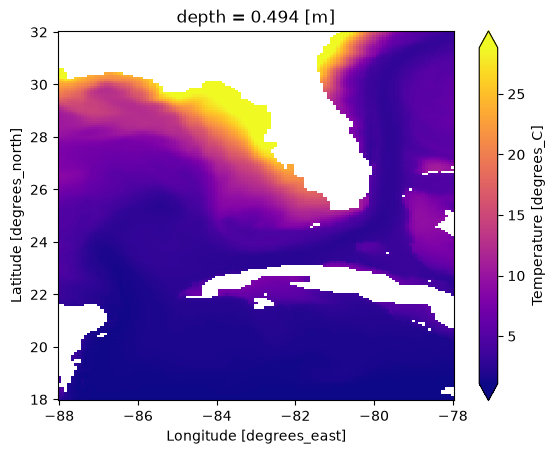

In [36]:
# Spatial Variance
sst_data.var(dim="time").plot(cmap="plasma", robust=True)

In [40]:
import numpy as np

# Compute global stats
mean_val = float(sst_data.mean())
std_val = float(sst_data.std())

# Define bounds
bounds_1std = (mean_val - std_val, mean_val + std_val)
bounds_2std = (mean_val - 2 * std_val, mean_val + 2 * std_val)

# Extract non-null grid points as a flat array
flat_data = sst_data.values.flatten()
flat_data = flat_data[~np.isnan(flat_data)]
total_points = len(flat_data)

# Count points within 1 and 2 std dev
count_1std = np.sum((flat_data >= bounds_1std[0]) & (flat_data <= bounds_1std[1]))
count_2std = np.sum((flat_data >= bounds_2std[0]) & (flat_data <= bounds_2std[1]))

# Calculate exact percentages
pct_1std = (count_1std / total_points) * 100
pct_2std = (count_2std / total_points) * 100

print(f"Mean: {mean_val:.2f} °C | Std Dev: {std_val:.2f} °C\n")
print(f"Exact Grid Points within Mean ± 1 Std Dev ({bounds_1std[0]:.2f}°C to {bounds_1std[1]:.2f}°C): {pct_1std:.2f}%")
print(f"Exact Grid Points within Mean ± 2 Std Dev ({bounds_2std[0]:.2f}°C to {bounds_2std[1]:.2f}°C): {pct_2std:.2f}%")

Mean: 26.74 °C | Std Dev: 2.84 °C

Exact Grid Points within Mean ± 1 Std Dev (23.89°C to 29.58°C): 74.68%
Exact Grid Points within Mean ± 2 Std Dev (21.05°C to 32.42°C): 95.17%


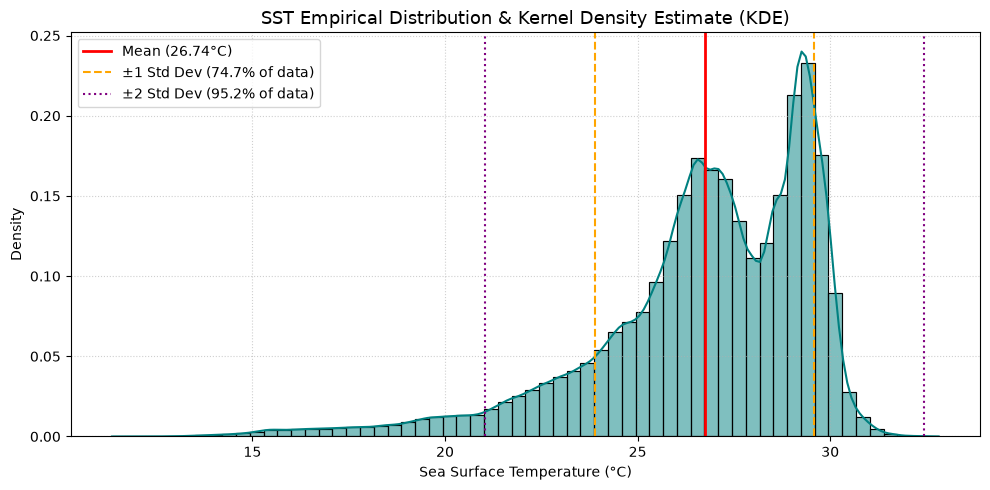

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))

# Plot histogram with KDE curve
sns.histplot(flat_data, bins=60, kde=True, color="teal", stat="density", alpha=0.5)

# Add Mean and Standard Deviation boundary lines
plt.axvline(mean_val, color="red", linestyle="-", linewidth=2, label=f"Mean ({mean_val:.2f}°C)")
plt.axvline(bounds_1std[0], color="orange", linestyle="--", label=f"±1 Std Dev ({pct_1std:.1f}% of data)")
plt.axvline(bounds_1std[1], color="orange", linestyle="--")
plt.axvline(bounds_2std[0], color="purple", linestyle=":", label=f"±2 Std Dev ({pct_2std:.1f}% of data)")
plt.axvline(bounds_2std[1], color="purple", linestyle=":")

plt.title("SST Empirical Distribution & Kernel Density Estimate (KDE)", fontsize=13)
plt.xlabel("Sea Surface Temperature (°C)")
plt.ylabel("Density")
plt.legend()
plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()

In [44]:
# Compute key percentiles
quantiles = np.percentile(flat_data, [5, 25, 50, 75, 95])

print(f" 5th Percentile: {quantiles[0]:.2f} °C (Coldest 5% threshold)")
print(f"25th Percentile (Q1): {quantiles[1]:.2f} °C")
print(f"50th Percentile (Median): {quantiles[2]:.2f} °C")
print(f"75th Percentile (Q3): {quantiles[3]:.2f} °C")
print(f"95th Percentile: {quantiles[4]:.2f} °C (Warmest 5% threshold)")

 5th Percentile: 21.16 °C (Coldest 5% threshold)
25th Percentile (Q1): 25.49 °C
50th Percentile (Median): 27.17 °C
75th Percentile (Q3): 29.00 °C
95th Percentile: 29.95 °C (Warmest 5% threshold)


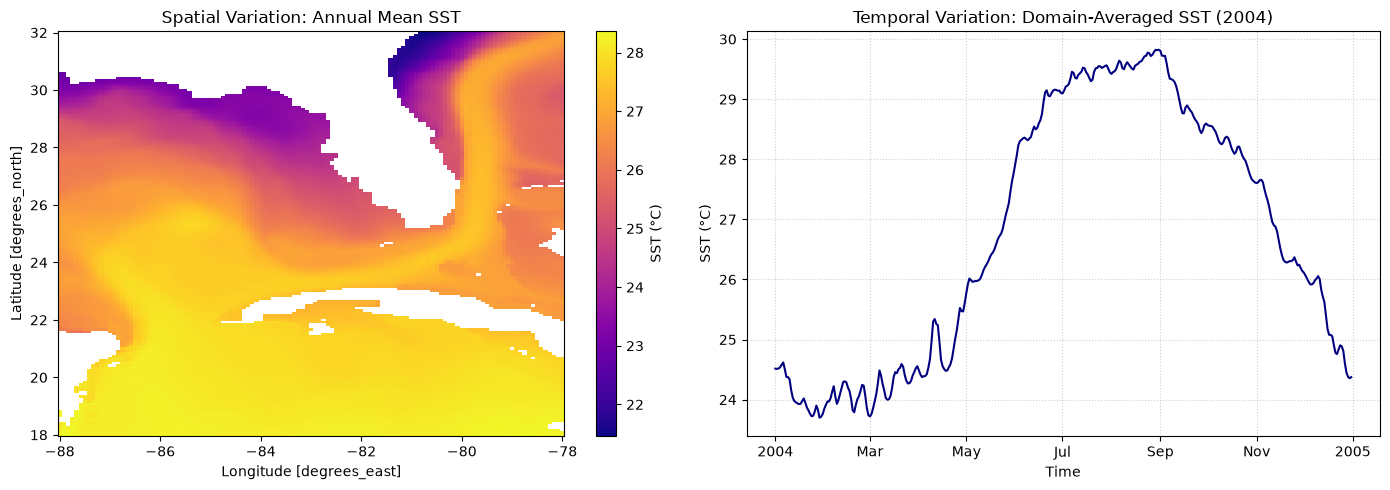

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Spatial Variation (Time-Averaged SST Map)
sst_data.mean(dim="time").plot(ax=axes[0], cmap="plasma", cbar_kwargs={"label": "SST (°C)"})
axes[0].set_title("Spatial Variation: Annual Mean SST")

# 2. Temporal Variation (Domain-Averaged Time Series)
sst_data.mean(dim=["latitude", "longitude"]).plot(ax=axes[1], color="navy")
axes[1].set_title("Temporal Variation: Domain-Averaged SST (2004)")
axes[1].set_ylabel("SST (°C)")
axes[1].grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()

In [47]:
# 1. Compute multi-year daily climatology (mean for each day of the year)
climatology = sst_data.groupby("time.dayofyear").mean(dim="time")

# 2. Subtract climatology to get Sea Surface Temperature Anomalies (SSTA)
ssta_data = sst_data.groupby("time.dayofyear") - climatology

In [52]:
import numpy as np
import pandas as pd

target_date = "2004-07-01"
target_dt = pd.to_datetime(target_date)

# 1. Target SST map
target_sst = sst_data.sel(time=target_date)

# 2. Extract day of year for the target date
target_doy = target_dt.dayofyear

# 3. Define calendar search window (+/- 30 days around target)
doy_diff = np.abs(sst_data.time.dt.dayofyear - target_doy)

# Search within 30 days of the same season
search_mask = (doy_diff <= 30) & (doy_diff > 7)

historical_pool = sst_data.where(search_mask, drop=True)

# 4. Compute spatial RMSD
rmsd = np.sqrt(((historical_pool - target_sst) ** 2).mean(dim=["latitude", "longitude"]))

# 5. Extract Top K analogs
K = 5
top_k = rmsd.sortby(rmsd).isel(time=slice(0, K))

# Display results
print(f"--- Top {K} Seasonal Analog Matches for Target Date ({target_date}) ---")
for rank, (t, val) in enumerate(zip(top_k.time.values, top_k.values), 1):
    date_str = pd.to_datetime(t).strftime("%Y-%m-%d")
    print(f"Rank {rank}: Date = {date_str} | Spatial RMSD = {val:.4f} °C")

--- Top 5 Seasonal Analog Matches for Target Date (2004-07-01) ---
Rank 1: Date = 2004-07-09 | Spatial RMSD = 0.3827 °C
Rank 2: Date = 2004-07-10 | Spatial RMSD = 0.3894 °C
Rank 3: Date = 2004-06-20 | Spatial RMSD = 0.3936 °C
Rank 4: Date = 2004-06-21 | Spatial RMSD = 0.4084 °C
Rank 5: Date = 2004-06-23 | Spatial RMSD = 0.4089 °C


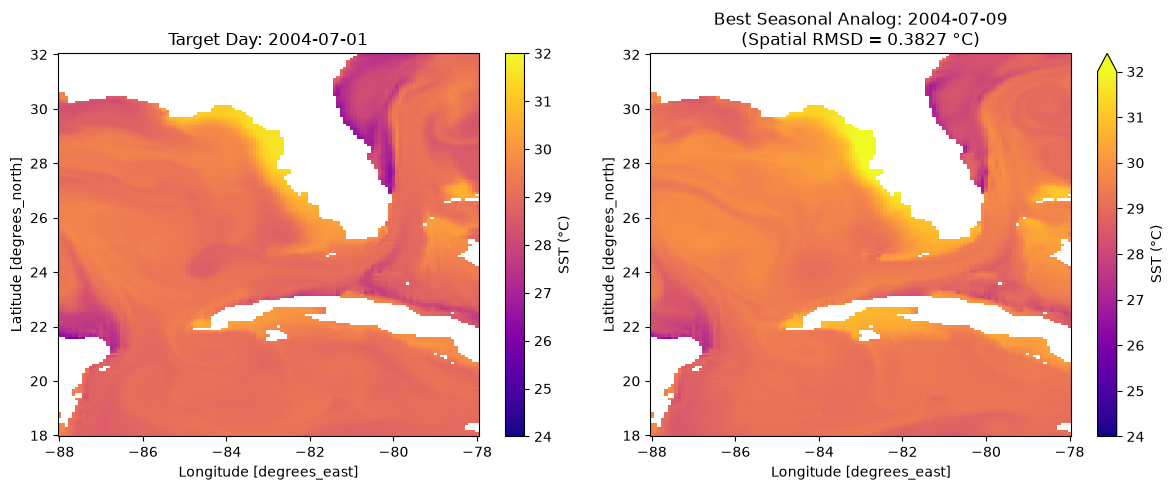

In [54]:
import matplotlib.pyplot as plt
import pandas as pd

# Extract the top 1 analog date and RMSD value
top_k_times = top_k.time.values
top_k_scores = top_k.values

best_analog_date = pd.to_datetime(top_k_times[0]).strftime("%Y-%m-%d")
best_rmsd_score = top_k_scores[0]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 1. Target SST Map
target_sst.plot(
    ax=axes[0], 
    cmap="plasma", 
    vmin=24, 
    vmax=32, 
    cbar_kwargs={"label": "SST (°C)"}
)
axes[0].set_title(f"Target Day: {target_date}")

# 2. Best Analog SST Map
sst_data.sel(time=best_analog_date).plot(
    ax=axes[1], 
    cmap="plasma", 
    vmin=24, 
    vmax=32, 
    cbar_kwargs={"label": "SST (°C)"}
)
axes[1].set_title(f"Best Seasonal Analog: {best_analog_date}\n(Spatial RMSD = {best_rmsd_score:.4f} °C)")

plt.tight_layout()
plt.show()

In [58]:
import numpy as np
from scipy.spatial.distance import cdist
import pandas as pd

def extract_front_points(sst_grid, threshold_grad=0.05):
    """
    Extracts grid index coordinates (i, j) where spatial SST gradient is high.
    Replaces NaNs with nearest values first to prevent gradient leakage on coasts.
    """
    # Create a clean copy and handle NaNs (land mask)
    grid_clean = np.nan_to_num(sst_grid, nan=np.nanmean(sst_grid))
    
    # Compute spatial gradients across grid dimensions
    dy, dx = np.gradient(grid_clean)
    grad_mag = np.sqrt(dx**2 + dy**2)
    
    # Mask out land from gradient calculation
    grad_mag[np.isnan(sst_grid)] = 0.0
    
    # Extract index pairs (row, col) above gradient threshold
    front_indices = np.where(grad_mag > threshold_grad)
    
    # Stack into an (N, 2) point array
    points = np.column_stack((front_indices[0], front_indices[1]))
    return points

def compute_mhd(set_A, set_B):
    """Computes Modified Hausdorff Distance between two 2D point sets A and B."""
    if len(set_A) == 0 or len(set_B) == 0:
        return np.inf  # Handle empty front edge cases
        
    d_matrix = cdist(set_A, set_B, metric='euclidean')
    d_A_B = np.mean(np.min(d_matrix, axis=1))
    d_B_A = np.mean(np.min(d_matrix, axis=0))
    return max(d_A_B, d_B_A)

# --- Compute MHD across Search Window ---
target_points = extract_front_points(target_sst.values, threshold_grad=0.05)

mhd_scores = {}
for time_step in historical_pool.time.values:
    hist_sst = historical_pool.sel(time=time_step).values
    hist_points = extract_front_points(hist_sst, threshold_grad=0.05)
    
    # Measure structural match
    score = compute_mhd(target_points, hist_points)
    mhd_scores[time_step] = score

# Sort and select Top K analogs via MHD
mhd_series = pd.Series(mhd_scores)
top_k_mhd = mhd_series.sort_values().head(5)

for rank, (t_val, score) in enumerate(top_k_mhd.items(), 1):
    date_str = pd.to_datetime(t_val).strftime("%Y-%m-%d")
    print(f"Rank {rank}: Date = {date_str} | MHD = {score:.4f} grid units")

Rank 1: Date = 2004-07-09 | MHD = 0.5797 grid units
Rank 2: Date = 2004-07-10 | MHD = 0.5855 grid units
Rank 3: Date = 2004-07-11 | MHD = 0.6277 grid units
Rank 4: Date = 2004-06-23 | MHD = 0.6403 grid units
Rank 5: Date = 2004-07-12 | MHD = 0.6412 grid units
